# Chemistry Graph Neural Network with Chemprop
In this example we will work with the solubility data again. We will use chemprop for our predictions, rather than write our own GNN.

# Install Packages
Only run if you do not have packages installed

In [ ]:
%pip install rdkit
%pip install pandas
%pip install scikit-learn
%pip install matplotlib
%pip install torch torchvision torchaudio #note this will install pytorch for CPU
%pip install chemprop

# Load data

In [56]:
from lightning import pytorch as pl
from lightning.pytorch.callbacks import ModelCheckpoint
import pandas as pd

from chemprop import data, featurizers, models, nn
import numpy as np

df = pd.read_csv("delaney.csv")

smiles_column = "SMILES"
target_columns = ["measured log(solubility:mol/L)"] #if you have multiple things you want to predict you can list them

# Prepare data for Chemprop

In [57]:
smis = df.loc[:, smiles_column].values
ys = df.loc[:, target_columns].values
num_workers = 0
#makes molecules for each SMILES
all_data = [data.MoleculeDatapoint.from_smi(smi, y) for smi, y in zip(smis, ys)]

mols = [d.mol for d in all_data]  # RDkit Mol objects are use for structure based splits
#split data, Chemprop supports scaffold splits
#change random to scaffold_balanced to split by scaffold, this will be a more rigorous test of the model
train_indices, val_indices, test_indices = data.make_split_indices(mols, "random", (0.8, 0.1, 0.1))  # unpack the tuple into three separate lists
train_data, val_data, test_data = data.split_data_by_indices(
    all_data, train_indices, val_indices, test_indices
)

featurizer = featurizers.SimpleMoleculeMolGraphFeaturizer()

train_dset = data.MoleculeDataset(train_data[0], featurizer)

val_dset = data.MoleculeDataset(val_data[0], featurizer)

test_dset = data.MoleculeDataset(test_data[0], featurizer)

train_loader = data.build_dataloader(train_dset, num_workers=num_workers)
val_loader = data.build_dataloader(val_dset, num_workers=num_workers, shuffle=False)
test_loader = data.build_dataloader(test_dset, num_workers=num_workers, shuffle=False)

The return type of make_split_indices has changed in v2.1 - see help(make_split_indices)


# Set up chemprop model

In [58]:
#choose message passing type (bond or atom)
mp = nn.BondMessagePassing()
#choose aggregation type
agg = nn.MeanAggregation()
#choose feed foward layers that lead to output
ffn = nn.RegressionFFN()
batch_norm = True
metric_list = [nn.metrics.RMSE(), nn.metrics.MAE()] # Only the first metric is used for training and early stopping

#construct the model
mpnn = models.MPNN(mp, agg, ffn, batch_norm, metric_list)

# Train model

In [59]:
# Configure model checkpointing
checkpointing = ModelCheckpoint(
    "checkpoints",  # Directory where model checkpoints will be saved
    "best-{epoch}-{val_loss:.2f}",  # Filename format for checkpoints, including epoch and validation loss
    "val_loss",  # Metric used to select the best checkpoint (based on validation loss)
    mode="min",  # Save the checkpoint with the lowest validation loss (minimization objective)
    save_last=True,  # Always save the most recent checkpoint, even if it's not the best
)


trainer = pl.Trainer(
    logger=False,
    enable_checkpointing=True, # Use `True` if you want to save model checkpoints. The checkpoints will be saved in the `checkpoints` folder.
    enable_progress_bar=True,
    accelerator="auto",
    devices=1,
    max_epochs=20, # number of epochs to train for
    callbacks=[checkpointing], # Use the configured checkpoint callback
)

trainer.fit(mpnn, train_loader, val_loader)

GPU available: False, used: False
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
Loading `train_dataloader` to estimate number of stepping batches.


┏━━━┳━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name            ┃ Type               ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ message_passing │ BondMessagePassing │  227 K │ train │     0 │
│ 1 │ agg             │ MeanAggregation    │      0 │ train │     0 │
│ 2 │ bn              │ BatchNorm1d        │    600 │ train │     0 │
│ 3 │ predictor       │ RegressionFFN      │ 90.6 K │ train │     0 │
│ 4 │ X_d_transform   │ Identity           │      0 │ train │     0 │
│ 5 │ metrics         │ ModuleList         │      0 │ train │     0 │
└───┴─────────────────┴────────────────────┴────────┴───────┴───────┘

Trainable params: 318 K                                                                                            
Non-trainable params: 0                                                                                            
Total params: 318 K                                                                                                
Total estimated model params size (MB): 1                                                                          
Modules in train mode: 25                                                                                          
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

`Trainer.fit` stopped: `max_epochs=20` reached.


# Test model

Restoring states from the checkpoint path at C:\Users\allis\OneDrive\work\teaching\Programming_and_AI_ChemBioChem\AIChemBiochem\10_Graph_neural_networks\checkpoints\best-epoch=19-val_loss=0.35.ckpt
Loaded model weights from the checkpoint at C:\Users\allis\OneDrive\work\teaching\Programming_and_AI_ChemBioChem\AIChemBiochem\10_Graph_neural_networks\checkpoints\best-epoch=19-val_loss=0.35.ckpt


┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃        Test metric        ┃       DataLoader 0        ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│         test/mae          │    0.39690837264060974    │
│         test/rmse         │    0.5345935821533203     │
└───────────────────────────┴───────────────────────────┘

Restoring states from the checkpoint path at C:\Users\allis\OneDrive\work\teaching\Programming_and_AI_ChemBioChem\AIChemBiochem\10_Graph_neural_networks\checkpoints\best-epoch=19-val_loss=0.35.ckpt
Loaded model weights from the checkpoint at C:\Users\allis\OneDrive\work\teaching\Programming_and_AI_ChemBioChem\AIChemBiochem\10_Graph_neural_networks\checkpoints\best-epoch=19-val_loss=0.35.ckpt


┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃        Test metric        ┃       DataLoader 0        ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│         test/mae          │    0.4289049804210663     │
│         test/rmse         │    0.5943204760551453     │
└───────────────────────────┴───────────────────────────┘

Restoring states from the checkpoint path at C:\Users\allis\OneDrive\work\teaching\Programming_and_AI_ChemBioChem\AIChemBiochem\10_Graph_neural_networks\checkpoints\best-epoch=19-val_loss=0.35.ckpt
Loaded model weights from the checkpoint at C:\Users\allis\OneDrive\work\teaching\Programming_and_AI_ChemBioChem\AIChemBiochem\10_Graph_neural_networks\checkpoints\best-epoch=19-val_loss=0.35.ckpt


┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃        Test metric        ┃       DataLoader 0        ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│         test/mae          │    0.4968859851360321     │
│         test/rmse         │    0.6713250875473022     │
└───────────────────────────┴───────────────────────────┘

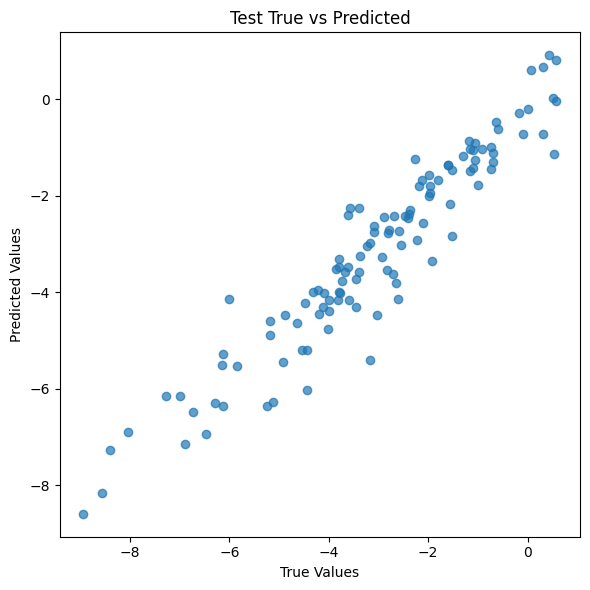

In [63]:
import matplotlib.pyplot as plt
import torch

#get training, val, test metrics
results = trainer.test(dataloaders=train_loader, weights_only=False)
results = trainer.test(dataloaders=val_loader, weights_only=False)
results = trainer.test(dataloaders=test_loader, weights_only=False)

#run predictions to plot actual vs predicted
with torch.inference_mode():
    test_preds = trainer.predict(mpnn, test_loader)
test_preds = np.concatenate(test_preds, axis=0)
    

ys = np.array([d.y[0] for d in test_dset])
plt.figure(figsize=(6, 6))
plt.scatter(ys, test_preds, alpha=0.7)
plt.xlabel("True Values")
plt.ylabel("Predicted Values")
plt.title(f"Test True vs Predicted")
plt.tight_layout()
plt.show()

